Using the 5 clusters from 3b, here is how the mall can better engage its customers:


Cluster 1 - Low income, low spenders: These customers are careful with money so the mall could attract them by offering discounts and affordable deals.


Cluster 2 - Low income, high spenders: These customers spend a lot despite earning less. The mall can target them with flash sales and limited time offers.


Cluster 3 - Middle income, average spenders: A fairly balanced group. Regular promotions and a loyalty programme would keep them coming back.


Cluster 4 - High income, low spenders: These customers earn well but are cautious spenders. The mall should focus on quality and exclusivity to win their trust.


Cluster 5 - High income, high spenders: The mall's best customers. Giving them VIP treatment like personalised services and early access to new products would keep them loyal.

3a (1 feature, k=3): When using only spending score, the clusters form horizontal bands. This means customers with very different incomes end up in the same group, which doesn't give us the full picture.


3b (2 features, k=5): Using both income and spending score gives us 5 clearly separated groups. You can actually see distinct clusters in the scatter plot which makes much more sense for understanding customer behaviour.


Conclusion: The 2 feature clustering is better because it considers more information about the customer, leading to more useful and realistic groups.

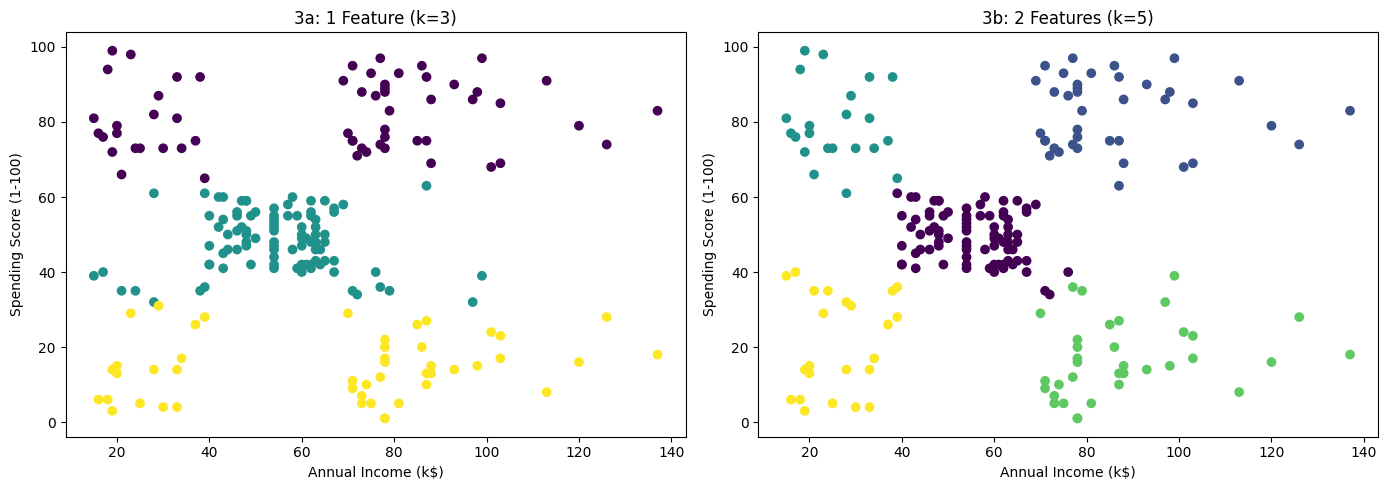

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster_1feat'], cmap='viridis')
ax1.set_title('3a: 1 Feature (k=3)')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')

ax2.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster_2feat'], cmap='viridis')
ax2.set_title('3b: 2 Features (k=5)')
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

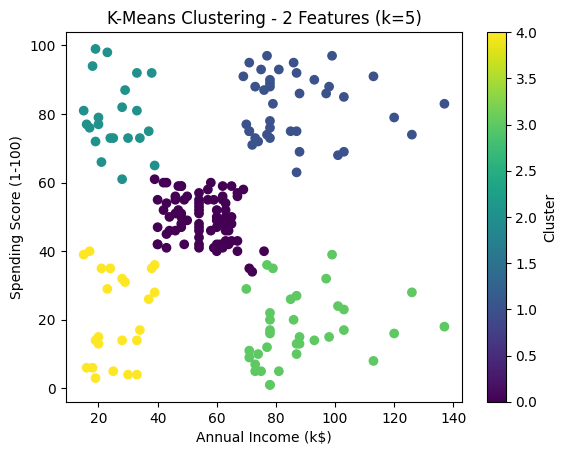

In [21]:
km2 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_2feat'] = km2.fit_predict(X2_scaled)

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster_2feat'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering - 2 Features (k=5)')
plt.colorbar(label='Cluster')
plt.show()

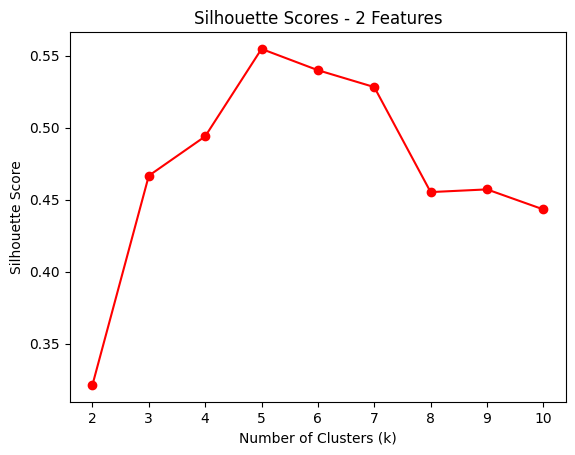

In [19]:
sil_scores2 = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X2_scaled)
    score = silhouette_score(X2_scaled, labels)
    sil_scores2.append(score)

plt.plot(range(2, 11), sil_scores2, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - 2 Features')
plt.show()

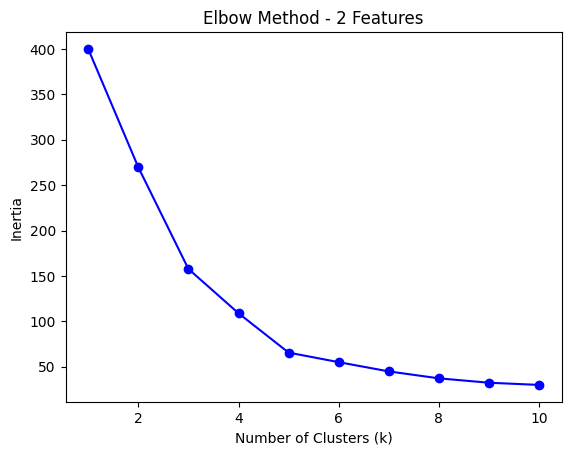

In [18]:
inertias2 = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X2_scaled)
    inertias2.append(km.inertia_)

plt.plot(range(1, 11), inertias2, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - 2 Features')
plt.show()

In [17]:
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
print("Data ready!")

Data ready!


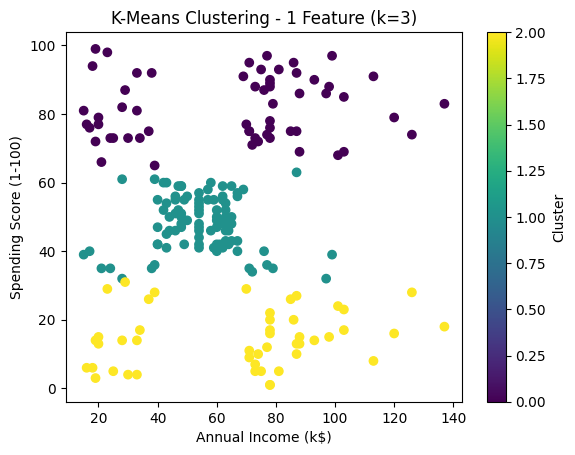

In [16]:
km1 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_1feat'] = km1.fit_predict(X1_scaled)

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster_1feat'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering - 1 Feature (k=3)')
plt.colorbar(label='Cluster')
plt.show()

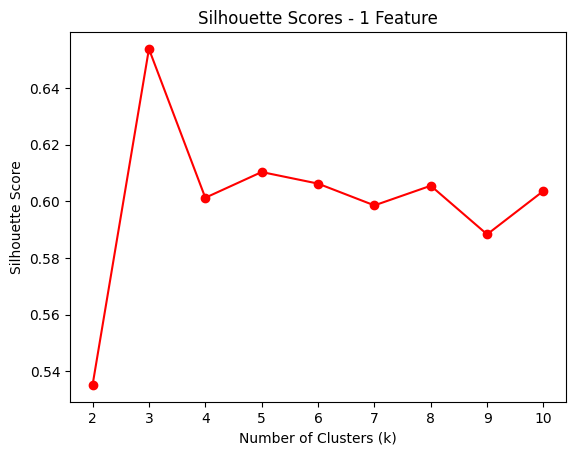

In [15]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X1_scaled)
    score = silhouette_score(X1_scaled, labels)
    sil_scores.append(score)

plt.plot(range(2, 11), sil_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - 1 Feature')
plt.show()

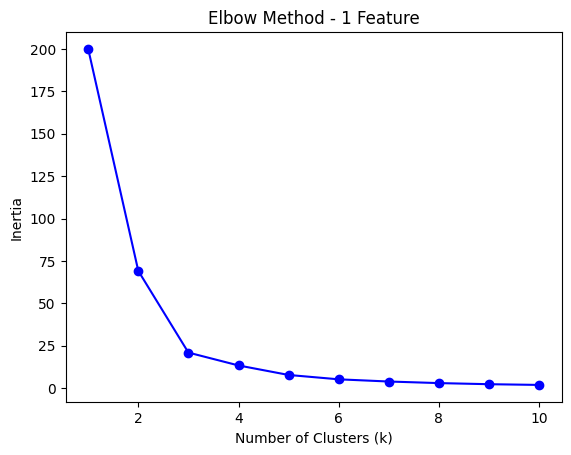

In [14]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X1_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - 1 Feature')
plt.show()

In [13]:
X1 = df[['Spending Score (1-100)']].values
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
print("Data ready!")

Data ready!


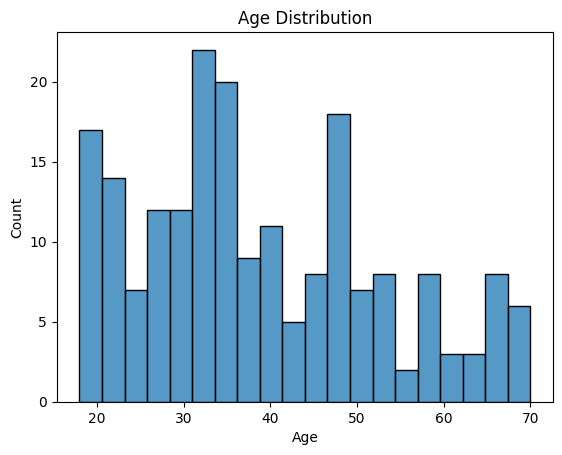

In [12]:
sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution')
plt.show()


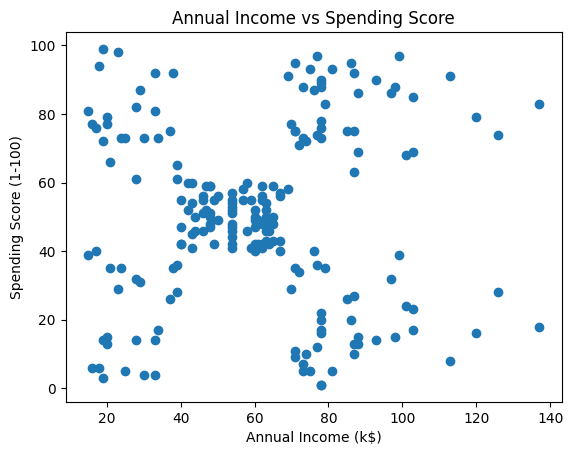

In [11]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()


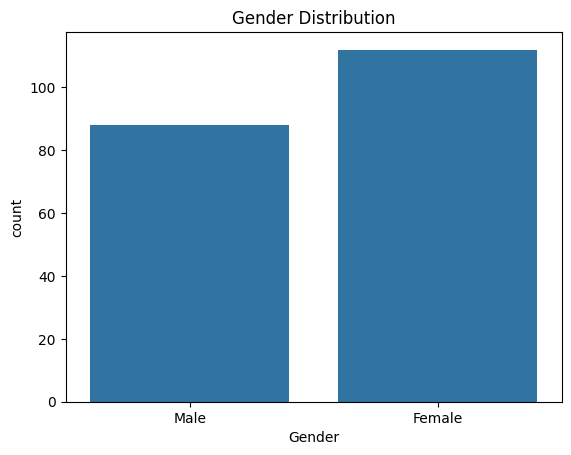

In [10]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [9]:
print(df.groupby('Gender')['Annual Income (k$)'].mean())

Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64


In [8]:
print(df.groupby('Gender')['Spending Score (1-100)'].mean())

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64


In [7]:
print(df['Gender'].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
print(df.duplicated().sum())


0


In [4]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("Libraries ready!")


Libraries ready!
